# Ch15. 비지도 학습

- 지도 학습: 예측 인자 X와 레이블 Z 사이의 매핑을 밝혀냄 ~ 지도: 데이터가 특정 변수 Z를 설명하도록 요청함
- 비지도 작업: Z가 지정되지 않고 알고리듬이 스스로 X를 이해하려고 시도함 ~ X의 구성 요소 간 관계 식별

[15.1] 상관관계가 있는 예측 인자의 문제점
$\\$(Ex) 예측 인자의 상관관계가 높은 경우: 공분산/상관계수가 1을 향해 증가하면 각 계수가 양/음수 되는 정도가 매우 심해짐
$\\ \rarr$ 두 계수 크기 매우 근접하기 때문에 순효과 상쇄 됨

In [ ]:
import import_ipynb
from Ch1 import data_ml, features, features_short
from Ch5 import training_sample

Index(['stock_id', 'date', 'Advt_12M_Usd', 'Advt_3M_Usd', 'Advt_6M_Usd',
       'Asset_Turnover', 'Bb_Yld', 'Bv', 'Capex_Ps_Cf', 'Capex_Sales',
       'Cash_Div_Cf', 'Cash_Per_Share', 'Cf_Sales', 'Debtequity', 'Div_Yld',
       'Dps', 'Ebit_Bv', 'Ebit_Noa', 'Ebit_Oa', 'Ebit_Ta', 'Ebitda_Margin',
       'Eps', 'Eps_Basic', 'Eps_Basic_Gr', 'Eps_Contin_Oper', 'Eps_Dil', 'Ev',
       'Ev_Ebitda', 'Fa_Ci', 'Fcf', 'Fcf_Bv', 'Fcf_Ce', 'Fcf_Margin',
       'Fcf_Noa', 'Fcf_Oa', 'Fcf_Ta', 'Fcf_Tbv', 'Fcf_Toa', 'Fcf_Yld',
       'Free_Ps_Cf', 'Int_Rev', 'Interest_Expense', 'Mkt_Cap_12M_Usd',
       'Mkt_Cap_3M_Usd', 'Mkt_Cap_6M_Usd', 'Mom_11M_Usd', 'Mom_5M_Usd',
       'Mom_Sharp_11M_Usd', 'Mom_Sharp_5M_Usd', 'Nd_Ebitda', 'Net_Debt',
       'Net_Debt_Cf', 'Net_Margin', 'Netdebtyield', 'Ni', 'Ni_Avail_Margin',
       'Ni_Oa', 'Ni_Toa', 'Noa', 'Oa', 'Ocf', 'Ocf_Bv', 'Ocf_Ce', 'Ocf_Margin',
       'Ocf_Noa', 'Ocf_Oa', 'Ocf_Ta', 'Ocf_Tbv', 'Ocf_Toa', 'Op_Margin',
       'Op_Prt_Margin', 'Oper_Ps_Net_

<string>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
stat=sm.OLS(training_sample['R1M_Usd'], sm.add_constant(training_sample[features])).fit()
# 중요한 예측 인자만을 보유
reg_thrhld=3
# 회귀 변수의 유의성 임계치
boo_filter=np.abs(stat.tvalues)>=reg_thrhld
# 추정
estimate=stat.params[boo_filter]
# 표준 오차
std_error=stat.bse[boo_filter]
# 통계량 
statistic=stat.tvalues[boo_filter]
# p-값
p_value=stat.pvalues[boo_filter]
significant_regressors=pd.concat([estimate, std_error, statistic, p_value], axis=1)
significant_regressors.columns=['estimat','std.error','statistic','p.value']
significant_regressors

,estimat,std.error,statistic,p.value
const,0.040715,0.005342,7.622191,2.505071e-14
Ebitda_Margin,0.013243,0.003493,3.791718,1.496529e-04
Ev_Ebitda,0.006782,0.002256,3.005943,2.647917e-03
Fa_Ci,0.007222,0.002347,3.077934,2.084699e-03
Fcf_Bv,0.025101,0.005131,4.891808,9.999185e-07
Fcf_Yld,-0.015997,0.003735,-4.282802,1.846412e-05
Mkt_Cap_12M_Usd,0.226810,0.022014,10.303229,6.912903e-25
Mkt_Cap_6M_Usd,-0.200716,0.043236,-4.642354,3.446830e-06
Mom_5M_Usd,-0.018807,0.004430,-4.245324,2.183775e-05
Mom_Sharp_11M_Usd,0.017743,0.004694,3.779522,1.571758e-04


<Axes: >

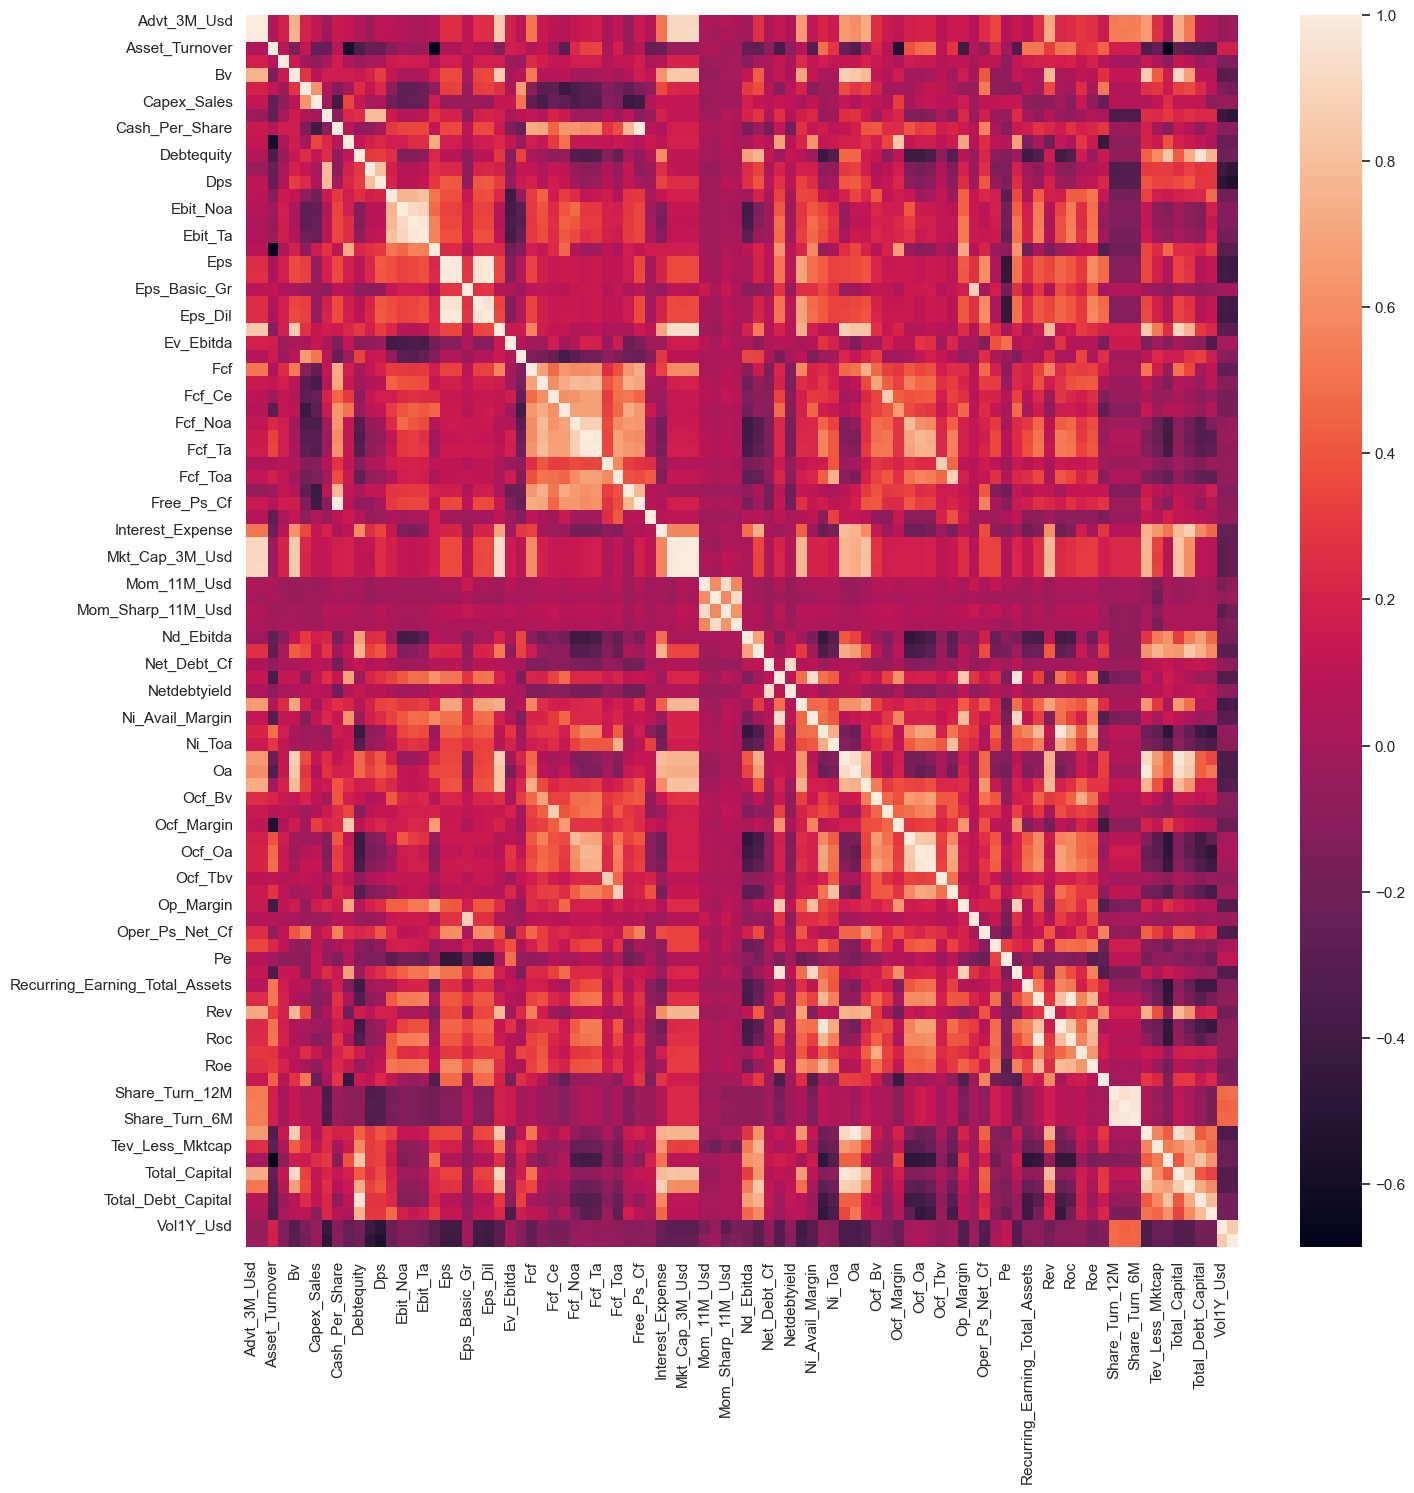

In [ ]:
# 시가 총액에 대한 지표 여러개 -> 하나만 사용해도 충분 but 어떤 지표가 최선의 선택인지 알기 어려움
import seaborn as sns
sns.set(rc={'figure.figsize':(16,16)})
sns.heatmap(training_sample[features].corr())

- 다중공선성: 순수한 통계적 추론에 비해 머신러닝 도구에서 훨씬 덜 문제
- 통계학: $\beta$ 계수의 특성 연구하는 게 핵심 목표
- 머신러닝: 표본 외 정확도를 극대화하는 게 목표
- Ex: in 회귀트리, 예측 인자 많으면 분할에 대한 옵션 많아짐 ~ 특성의 스펙트럼이 넓으면 모델의 일반화 능력을 향상시킴

[15.2] 주성분 분석과 오토인코더: 더 적은 수의 팩터(K'< K) 결정
1. 설명력 수준을 가능한 한 높게 유지
2. 결과 팩터가 원래 변수들의 선형 조합
3. 결과 팩터가 직교

- $I > K$ & $\textbf{X}'\textbf{X}=\textbf{I}_K$: $I \times K$ 차원의 행렬은 정규 직교 이룸
- $I=K$일 때, 직교 행렬이라 함 ~ $\textbf{X}'\textbf{X}=\textbf{X}\textbf{X}'=\textbf{I}_K \rarr \textbf{X}^{-1}=\textbf{X}'$
- 특이값 분해(SVD): 모든 $I\times K$행렬 $\textbf{X}=\textbf{U} \boldsymbol{\Delta} \textbf{V}'$로 분해 가능
- $\textbf{U}(I\times I),\ \textbf{V}(K\times K)$: 직교 & $\Delta(I \times K)$: 대각행렬 & 모두 양수
- $\textbf{X}$: 대칭인 경우, $\textbf{X}=\textbf{Q}\textbf{D}\textbf{Q}'$ ~ 직교행렬 Q

[15.2.2] PCA
- 직교행렬(Orthogonal matrix): $X'X = I$ (단위 행렬)가 되는 행렬
- 특이값 분해(SVD): 모든 행렬 $X$는 $X = U\Delta V'$ 형태로 쪼갤 수 있음
- 대칭행렬: $X = QDQ'$ 형태로 분해 가능 ~ Q(orthogonal): 고유벡터로 구성됨, D: 고유값들이 대각선에 위치
1. 기저 변환: 원본 데이터 $X$를 새로운 데이터 $Z$로 변환 ~ $Z=XP$, P: 데이터 회전시키는 변환 행렬
2. 제약 조건: (i) 상관관계 제거(Z의 공분산 행렬이 대각 행렬) (ii) Z의 첫 번째 열에 가장 많은 정보(분산) 담김 -> 뒤로 갈수록 정보량 감소

Step:
1. $$\Sigma_Z = \frac{1}{I-1} Z'Z = \frac{1}{I-1} P'\Sigma_X P$$
2. $$\Sigma_Z = \frac{1}{I-1} P' (QDQ') P$$
3. 변환행렬 $P$를 $Q$로 선택, $Q'Q = I$, $$\Sigma_Z = \frac{1}{I-1} D$$
- P=Q: 원본 데이터의 공분산 행렬을 대각화해주는 고유벡터(Q)를 사용하여 데이터를 회전시키면 변수 간의 상관관계 모두 사라짐
- D: 각 새로운 변수(Z)의 분산(정보량) 의미
- Z: X를 선형 변환한 것이므로 코딩된 정보가 다르더라도 동일한 정보 전달
- 열: 상대적 중요도에 따라 정렬되므로 일부 열 생략 가능

In [ ]:
from sklearn import decomposition
# 요소 개수 부과
pca=decomposition.PCA(n_components=7)
# 적은 수의 예측 인자에 대해 PCA 수행
pca.fit(training_sample[features_short]) # 공분산 행렬의 고유벡터
# 구성 요소별 설명하는 분산 확인
print(pca.explained_variance_ratio_)
# 회전 (n x k) = (7 x 7)
P=pd.DataFrame(pca.components_, columns=features_short).T
# 열 이름 정리
P.columns=['P'+str(col) for col in P.columns] 
P

[0.35718238 0.1940806  0.15561321 0.10434453 0.09601422 0.07017118
 0.02259388]


,P0,P1,P2,P3,P4,P5,P6
Div_Yld,0.271599,-0.579099,-0.045725,0.528956,-0.226626,0.506566,0.032012
Eps,0.420407,-0.150082,0.024767,-0.337373,0.771377,0.301883,0.011965
Mkt_Cap_12M_Usd,0.523868,0.343239,-0.172289,-0.062495,-0.252781,0.002987,0.714319
Mom_11M_Usd,0.047238,0.057714,0.897160,-0.241015,-0.250559,0.258477,0.043179
Ocf,0.532947,0.195890,-0.185039,-0.234371,-0.357596,0.049015,-0.676866
Pb,0.152413,0.580806,0.221048,0.682136,0.308665,0.038675,-0.168799
Vol1Y_Usd,-0.406890,0.381139,-0.282162,-0.155411,-0.061575,0.762588,0.008632


In [ ]:
!pip install pca


   -------------------------------- ------- 4/5 [pca]
   ---------------------------------------- 5/5 [pca]



[04-02-2026 21:04:01] [pca.pca] [INFO] Extracting row labels from dataframe.
[04-02-2026 21:04:01] [pca.pca] [INFO] The PCA reduction is performed on 7 variables (columns) of the input dataframe.
[04-02-2026 21:04:01] [pca.pca] [INFO] Fit using PCA.
[04-02-2026 21:04:01] [pca.pca] [INFO] Compute loadings and PCs.
[04-02-2026 21:04:01] [pca.pca] [INFO] Compute explained variance.
[04-02-2026 21:04:01] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[7]
[04-02-2026 21:05:36] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[04-02-2026 21:05:36] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[04-02-2026 21:06:50] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[04-02-2026 21:06:51] [scatterd.scatterd] [INFO] Create scatterplot


(<Figure size 2500x1500 with 1 Axes>,
 <Axes: title={'center': 'The top 7 Principal Component(s) explains [100.0%] of the variance.'}, xlabel='PC1 (35.7% expl.var)', ylabel='PC2 (19.4% expl.var)'>)

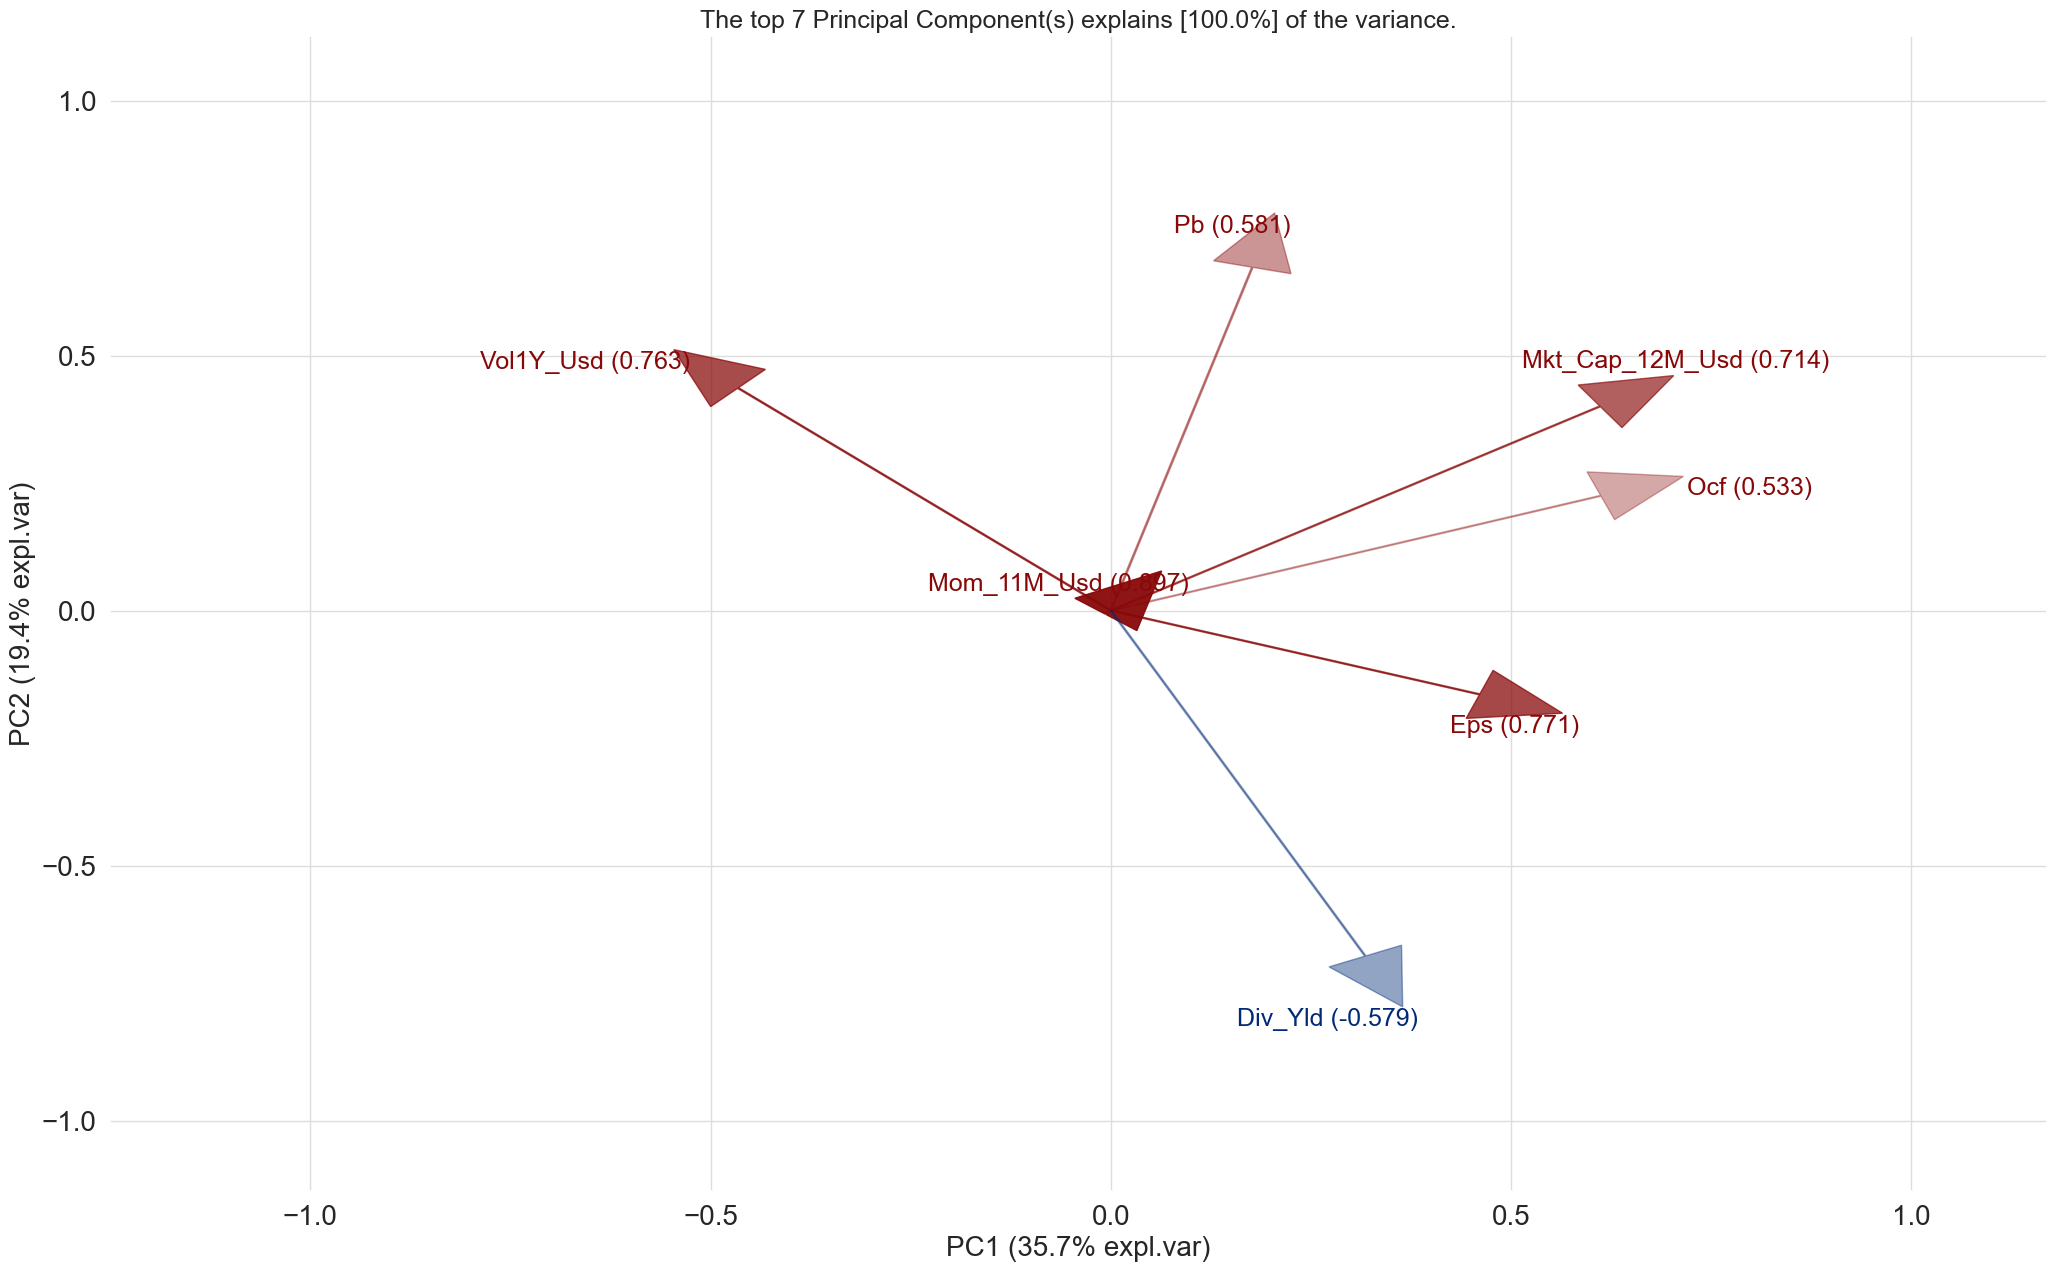

In [ ]:
from pca import pca
model=pca(n_components=7)
# 변환을 피팅시킴
results=model.fit_transform(
    training_sample[features_short], col_labels=features_short
)
# 2차원 그래프 생성
model.biplot(n_feat=7, PC=[0,1], cmap=None, label=None, legend=False)

- 축 따라 표시된 숫자: 각 PC의 설명 분산 비율

In [ ]:
pd.DataFrame(
    np.matmul(training_sample[features_short].values, P.values[:,:4]), columns=['PC1','PC2','PC3','PC4']
).head()

,PC1,PC2,PC3,PC4
0,-0.032605,0.553557,-0.032021,0.274928
1,-0.066614,0.621318,-0.053449,0.218684
2,-0.069685,0.650055,0.062423,0.174365
3,-0.075235,0.492199,-0.206870,0.372216
4,-0.115116,0.549612,-0.189423,0.312871


- 이 네가지 팩터는 모든 머신러닝 엔진에서 직교된 특성들로 사용 가능
- but 이 특성들을 더 이상 바로 해석할 수는 없음

[15.2.3] 오토인코더

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
# features_short: 7개의 열 가짐
input_layer=Input(shape=(7,))
# 1. 인코드
encoder=tf.keras.layers.Dense(units=32, activation='sigmoid')(input_layer)
# 2. PCA 예시와 동일하게 출력 레이어는 4차원 가짐
encoder=tf.keras.layers.Dense(units=4)(encoder)
# 3. 인코더로부터 디코드함
decoder=tf.keras.layers.Dense(units=32, activation='sigmoid')(encoder)
# 4. 원본 샘플은 7개의 특성 가짐
decoder=tf.keras.layers.Dense(units=7)(decoder)

In [ ]:
# 모델 구성
from tensorflow import keras
ae_model=keras.Model(input_layer, decoder)
ae_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])

In [ ]:
from Ch5 import testing_sample
NN_train_features=training_sample[features_short].values
NN_test_features=testing_sample[features_short].values
history=ae_model.fit(NN_train_features, NN_train_features, epochs=15, batch_size=512, validation_data=(NN_test_features, NN_test_features))
ae_weights=ae_model.get_weights()

Epoch 1/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1404 - mean_squared_error: 0.1404 - val_loss: 0.0593 - val_mean_squared_error: 0.0593
Epoch 2/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0510 - mean_squared_error: 0.0510 - val_loss: 0.0410 - val_mean_squared_error: 0.0410
Epoch 3/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0340 - mean_squared_error: 0.0340 - val_loss: 0.0250 - val_mean_squared_error: 0.0250
Epoch 4/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0197 - mean_squared_error: 0.0197 - val_loss: 0.0160 - val_mean_squared_error: 0.0160
Epoch 5/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0162 - mean_squared_error: 0.0162 - val_loss: 0.0155 - val_mean_squared_error: 0.0155
Epoch 6/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0155 - val_mean_squared_error: 0.0155
Epoch 7/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0158 - mean_squared_error: 0.0158 - val_loss: 0.01

[15.3] k-평균을 통한 클러스터링
- 동질적인 예측 인자 군으로 그룹화
- 변수 그룹 $\textbf{x}_{\{1 \le j \le J\}}$ 중에서 다음을 최소화하는 $k<J$ 그룹의 조합 찾기
$\\ \sum_{i=1}^k\sum_{\textbf{x}\in S_i}||\textbf{x}-\textbf{m}_i||^2$
- 최적성 보장 위해 가능한 모든 배열들 테스트해야 함
- 휴리스틱적 방법:
0. k개의 클러스터로 구성된 파티션으로 시작
1. 각 클러스터에 대해 수식 최소화하는 최적의 평균값 $m_i^*$ 계산 
2. 최적의 중심값 $m_i^*$가 주어지면 점 $x_i$를 모두 중심에 가깝게 재할당
3. 2단계에서 점의 군집이 변하지 않을 때까지 1, 2 단계 반복

In [ ]:
from sklearn import cluster
# 클러스터 개수 설정
k_means=cluster.KMeans(n_clusters=10)
# k-평균 클러스터링 수행
k_means.fit(training_sample[features].T)
# 클러스터 데이터 조직화
clusters=pd.DataFrame([features, k_means.labels_], index=['factore', 'cluster']).T
# 1개의 특정 그룹
clusters.loc[clusters['cluster']==4]

Exception in thread Thread-611 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\82103\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\82103\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Users\82103\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\82103\anaconda3\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "<frozen codecs>", line 325, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte
c:\Users\82103\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You c

,factore,cluster
42,Mom_11M_Usd,4
43,Mom_5M_Usd,4
44,Mom_Sharp_11M_Usd,4
45,Mom_Sharp_5M_Usd,4


[15.4] 최근접 이웃
1. 훈련 샘플이 (y, X)의 분포를 정확하게 포괄할 수 있음
2. 테스트 샘플이 훈련 샘플과 동일한 분포(or 충분히 가까운 분포)를 따르는 경우
- 훈련 샘플에서 계산된 테스트 특성, & 그 특성으로부터의 한 인스턴스 $x_i$의 이웃은 $y_i$에 대한 유용한 정보 얻을 수 있음
- 이웃: 유사성 측정값 통해 정의 ~ $D(\textbf{x}_j,\textbf{x}_i)=\sum_{k=1}^Kc_k d_k(x_{j,k},x_{i,k})$
- 거리함수 $d_k$: 다양한 데이터 유형에서 작동 가능
- $c_k$: 특성에 가중치 부여해 약간의 유연성 허용
- 거리 계산 후: $D\left(\textbf{x}_{l_1^i},\textbf{x}_i\right) \le D\left(\textbf{x}_{l_2^i},\textbf{x}_i\right) \le \dots, \le D\left(\textbf{x}_{l_I^i},\textbf{x}_i\right)$
- 이웃 주어지면 레이블에 대한 예측 구성: $x_i$가 $x_j$에 가까우면 레이블 값 $y_i$도 $y_j$에 가까워야 함
- $\hat{y}_i=\frac{\sum_{j\neq i} h(D(\textbf{x}_j,\textbf{x}_i)) y_j}{\sum_{j\neq i} h(D(\textbf{x}_j,\textbf{x}_i))},$
- h: 감소 함수 ~ 거리 멀어질수록 가중치 작아짐 ~ 매개변수: 거리가 얼마나 불이익을 주는지 결정

In [ ]:
# 최근접 이웃 탐지 위한 패키지
from sklearn import neighbors as nb
# k-NN 연습 위한 데이터셋
knn_data=data_ml.loc[data_ml['date']=='2006-12-31', :]
# 목표 관측치
knn_target=knn_data.loc[knn_data['stock_id']==13, features]
# 그 외 다른 관측치
knn_sample=knn_data.loc[knn_data['stock_id']!=13, features]
# 사용한 이웃 개수
neighbors=nb.NearestNeighbors(n_neighbors=30)
neighbors.fit(knn_sample)

: 

In [ ]:
# 이웃과 거리 알려지면 목표 주식의 수익률 예측 계산 가능
neigh_dist, neigh_ind=neighbors.kneighbors(knn_target)
print(pd.DataFrame(neigh_ind))
knn_labels=knn_data.loc[:,'R1M_Usd'].values[neigh_ind]
np.sum(knn_labels*np.exp(-neigh_dist)/np.sum(np.exp(-neigh_dist)))
knn_data.loc[knn_data['stock_id']==13, 'R1M_Usd']